# 📊 Análisis de Riesgo Crediticio
## Dataset: Give Me Some Credit — Kaggle (2011)

Este análisis examina el comportamiento crediticio de **150,000 clientes**
de una institución financiera de EE.UU., con el objetivo de identificar
patrones de riesgo y segmentar clientes según su probabilidad de incumplimiento.

**Contexto:** El dataset fue publicado en 2011, en el período post-crisis
financiera del 2008, lo que explica la presencia de clientes con alto
endeudamiento y baja capacidad de pago.

In [ ]:
# ========================================
# Proyecto de análisis de Riesgo Crediticio
# Dataset utilizado: Give Me Some credit - Kaggle
# CARGA INICIAL
# ========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette('Blues_r')

df = pd.read_csv('cs-training.csv', index_col=0)
print(f"Dataset cargado: {df.shape[0]:,} filas | {df.shape[1]} columnas")

In [ ]:
# CARGA INICIAL
# COMPROBACIÓN DEL DATASET
print("=== PRIMERAS FILAS")
df.head(5)

=== PRIMERAS FILAS


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [ ]:
# CARGA INICIAL
# VERIFICANDO COLUMNAS
print("=== TIPOS DE DATOS ===")
print(df.dtypes)

=== TIPOS DE DATOS ===
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                        int64
PerfilRiesgo                             object
dtype: object


In [ ]:
# CARGA INICIAL
# ESTADÍSTICAS DEL DATASET
print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
df.describe().loc['mean':].round(2)


=== ESTADÍSTICAS DESCRIPTIVAS ===


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
mean,0.07,6.05,52.30,0.42,353.01,6670.22,8.45,0.27,1.02,0.24,0.76
std,0.25,249.76,14.77,4.19,2037.82,14384.67,5.15,4.17,1.13,4.16,1.12
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.03,41.00,0.00,0.18,3400.00,5.00,0.00,0.00,0.00,0.00
50%,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,0.00,0.56,63.00,0.00,0.87,8249.00,11.00,0.00,2.00,0.00,1.00
max,1.00,50708.00,109.00,98.00,329664.00,3008750.00,58.00,98.00,54.00,98.00,20.00


In [ ]:
# LIMPIEZA DE DATOS
# VALORES NULOS
print("=== VALORES NULOS POR COLUMNA ===")
nulos = pd.DataFrame({
    'Nulos': df.isnull().sum(),
    'porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
})
print(nulos[nulos['Nulos']>0])

=== VALORES NULOS POR COLUMNA ===
Empty DataFrame
Columns: [Nulos, porcentaje]
Index: []


In [ ]:
# LIMPIEZA DE DATOS
# RELLENANDO NULOS
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(0)

# Corrigiendo decimales
cols_enteras = [
    'NumberOfTimes90DaysLate',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines',
    'NumberOfDependents'
]
for col in cols_enteras:
    df[col] = df[col].round().astype(int)

# Verificando Outliers
df['DebtRatio'] = df['DebtRatio'].clip(upper=10)

# Dataset limpio para visualizaciones
df_viz = df[df['MonthlyIncome'] >= 100].copy()

print(f"df original: {len(df):,} clientes")
print(f"df_viz para gráficos: {len(df_viz):,} clientes")
print(f"Nulos restantes: {df.isnull().sum().sum()}")
print(f"Tasa de mora: {df['SeriousDlqin2yrs'].mean()*100:.1f}%")

df original: 150,000 clientes
df_viz para gráficos: 147,723 clientes
Nulos restantes: 0
Tasa de mora: 6.7%


## 🔧 Calidad de los Datos

Durante la limpieza se identificaron las siguientes limitaciones del dataset:

- **19.8% de clientes** no tenían ingreso mensual declarado → imputado con la mediana ($5,400).

Esto afecta el análisis de DebtRatio para ese segmento.
- **4 columnas** presentaban decimales en variables que deberían ser enteras
(atrasos, líneas de crédito) → corregidas a enteros.
- **28,994 clientes (19.3%)** tenían DebtRatio imposible en la realidad →
capeado en 10 como límite máximo razonable.
- **2,277 clientes** con ingreso menor a $100/mes fueron excluidos de las
visualizaciones por considerarse registros anómalos, pero conservados en el dataset original.

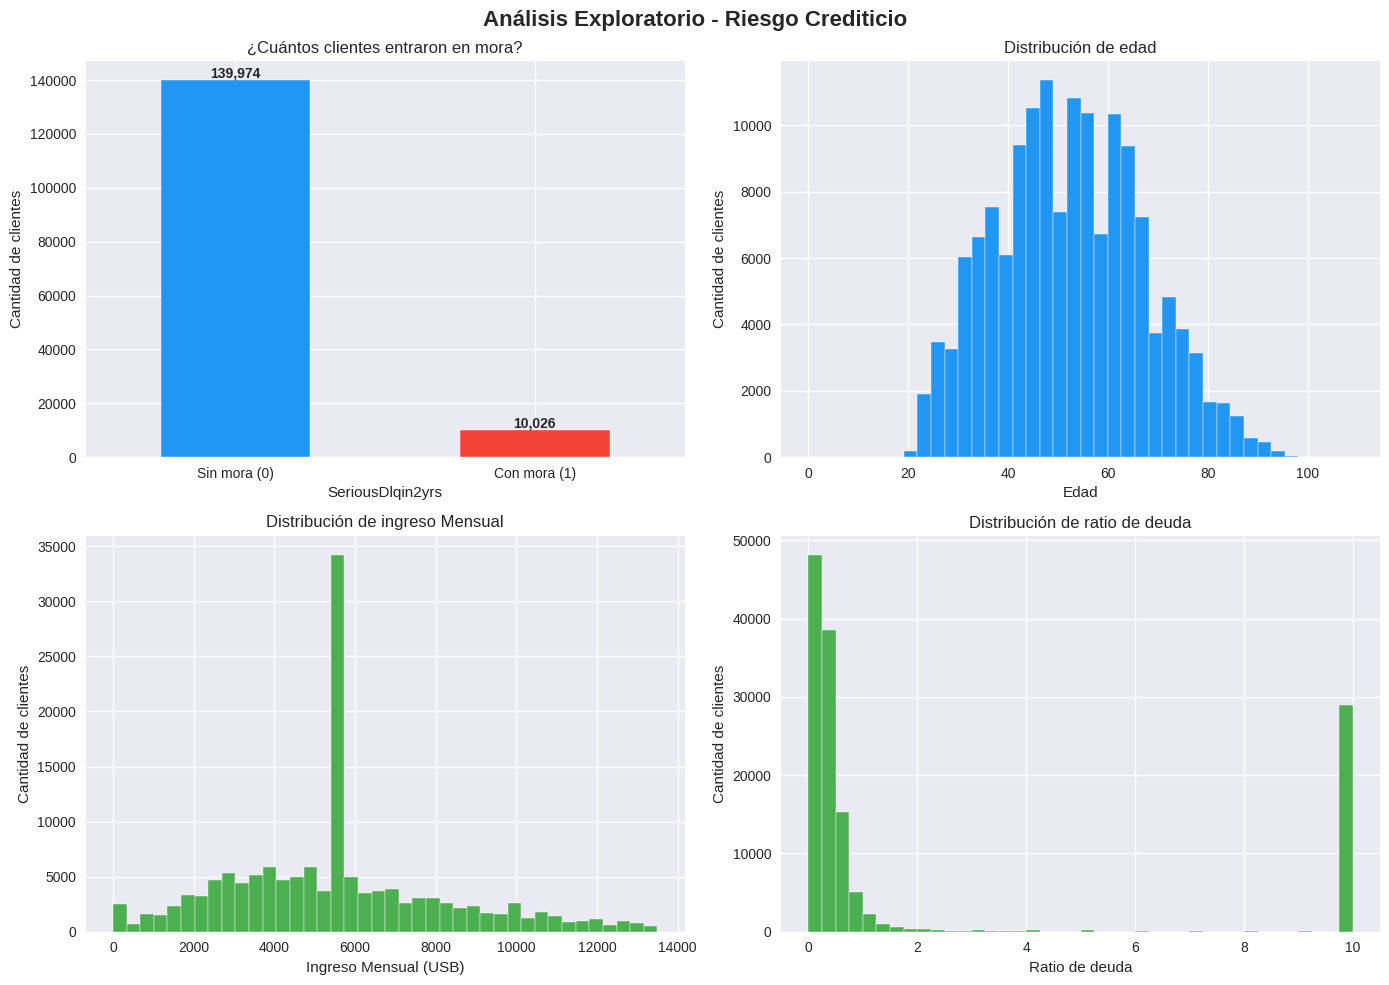

In [ ]:
# ANÁLISIS EXPLORTARIO - EDA
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis Exploratorio - Riesgo Crediticio', fontsize=16, fontweight = 'bold')

#Gráfico 1: Distribución de clientes en riesgo
axes[0,0].set_title('¿Cuántos clientes entraron en mora?')
colores = ['#2196F3', '#F44336']
df['SeriousDlqin2yrs'].value_counts().plot(
    kind='bar', ax=axes[0,0], color=colores, edgecolor='white'
)
axes[0,0].set_xticklabels(['Sin mora (0)', 'Con mora (1)'], rotation=0)
axes[0,0].set_ylabel('Cantidad de clientes')
for p in axes[0,0].patches:
    axes[0,0].annotate(f'{p.get_height():,.0f}',
                      (p.get_x() + p.get_width() / 2, p.get_height()),
                       ha='center', va='bottom', fontweight='bold')

# Gráfico 2: Distribución de edades
axes[0,1].set_title('Distribución de edad')
axes[0,1].hist(df['age'], bins=40, color='#2196F3', edgecolor='white')
axes[0,1].set_xlabel('Edad')
axes[0,1].set_ylabel('Cantidad de clientes')

# Gráfico 3: Ingreso mensual (sin outliers extremos)
axes[1,0].set_title('Distribución de ingreso Mensual')
ingreso_filtrado = df[df['MonthlyIncome'] < df['MonthlyIncome'].quantile(0.95)]
axes[1,0].hist(ingreso_filtrado['MonthlyIncome'], bins=40, color='#4CAF50',edgecolor='white')
axes[1,0].set_xlabel('Ingreso Mensual (USB)')
axes[1,0].set_ylabel('Cantidad de clientes')

# Gráfico 4: Ratio de deuda
axes[1,1].set_title('Distribución de ratio de deuda')
deuda_filtrada = df[df['MonthlyIncome']<df['MonthlyIncome'].quantile(0.95)]
axes[1,1].hist(deuda_filtrada['DebtRatio'], bins=40, color='#4CAF50',edgecolor='white')
axes[1,1].set_xlabel('Ratio de deuda')
axes[1,1].set_ylabel('Cantidad de clientes')

plt.tight_layout()
plt.show()

In [ ]:
# ANÁLISIS EXPLORTARIO - EDA
# DISTRIBUCIÓN DE DEBTRATIO
# ============================================

print("DISTRIBUCIÓN DE DEBTRATIO")
percentiles = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
for p in percentiles:
  print(f"Percentil {int(p*100)}%: {df['DebtRatio'].quantile(p):.2f}")

print(f"\nMáximo absoluto: {df['DebtRatio'].max():.2f}")
print(f"Cuántos clientes tienen DebtRatio > 10: {(df['DebtRatio'] > 10).sum():,}")
print(f"Cuántos clientes tienen DebtRatio > 1: {(df['DebtRatio'] > 1).sum():,}")


DISTRIBUCIÓN DE DEBTRATION
Percentil 25%: 0.18
Percentil 50%: 0.37
Percentil 75%: 0.87
Percentil 90%: 10.00
Percentil 95%: 10.00
Percentil 99%: 10.00

Máximo absoluto: 10.00
Cuántos clientes tienen DebtRatio > 10: 0
Cuántos clientes tienen DebtRatio > 1: 35,137


In [ ]:
# ANÁLISIS EXPLORTARIO - EDA
# ANÁLISIS DE INGRESOS BAJOS SOSPECHOSOS
# ============================================

salario_minimo_2011 = 1160  # USD mensual
umbral_70 = salario_minimo_2011 * 0.30  # 70% menor = 30% del mínimo = $348

print(f"Salario mínimo EE.UU. 2011: ${salario_minimo_2011:,}")
print(f"Umbral mínimo aceptable (30%): ${umbral_70:.0f}")

print(f"\nClientes con ingreso entre $1 y $348: {((df['MonthlyIncome'] > 0) & (df['MonthlyIncome'] < umbral_70)).sum():,}")
print(f"Clientes con ingreso = $0: {(df['MonthlyIncome'] == 0).sum():,}")
print(f"Clientes con ingreso < $100: {(df['MonthlyIncome'] < 100).sum():,}")

print(f"\nTotal clientes antes de filtrar: {len(df):,}")

Salario mínimo EE.UU. 2011: $1,160
Umbral mínimo aceptable (30%): $348

Clientes con ingreso entre $1 y $348: 873
Clientes con ingreso = $0: 1,634
Clientes con ingreso < $100: 2,277

Total clientes antes de filtrar: 150,000


## 💡 Insights Principales:

### 1. El dataset está desbalanceado
Solo el **6.7% de clientes** entró en mora — esto es típico en datasets bancarios
y debe considerarse al construir modelos predictivos futuros.

### 2. La segmentación predice correctamente el comportamiento
| Segmento | Clientes | Tasa de Mora |
|---|---|---|
| Bajo Riesgo | 112,436 (75%) | 2.3% |
| Riesgo Medio | 31,736 (21.2%) | 14.3% |
| Alto Riesgo | 5,828 (3.9%) | 50.7% |

Un cliente de **Alto Riesgo tiene 22 veces más probabilidad** de entrar
en mora que uno de Bajo Riesgo.

### 3. Los atrasos graves son el mejor predictor
Haber tenido **90+ días de atraso** es el indicador más fuerte de
incumplimiento futuro — más que el ingreso o la cantidad de deudas.

### 4. El perfil del cliente típico en mora
- Edad promedio: entre 40-60 años
- Ha tenido al menos 1 atraso de 90+ días
- Usa más del 75% de su límite de crédito disponible

In [ ]:
# ============================================
# SEGMENTACIÓN POR PERFIL DE RIESGO
# ============================================

def clasificar_riesgo(row):
    score = 0

    # Atrasos graves (peso alto)
    if row['NumberOfTimes90DaysLate'] >= 2:
        score += 3
    elif row['NumberOfTimes90DaysLate'] == 1:
        score += 2

    # Atrasos moderados
    if row['NumberOfTime60-89DaysPastDueNotWorse'] >= 1:
        score += 2

    # Atrasos leves
    if row['NumberOfTime30-59DaysPastDueNotWorse'] >= 2:
        score += 1

    # Uso de crédito
    if row['RevolvingUtilizationOfUnsecuredLines'] > 0.75:
        score += 2
    elif row['RevolvingUtilizationOfUnsecuredLines'] > 0.50:
        score += 1

    # Ratio de deuda
    if row['DebtRatio'] > 0.75:
        score += 1

    # Clasificación final
    if score >= 5:
        return 'Alto Riesgo'
    elif score >= 2:
        return 'Riesgo Medio'
    else:
        return 'Bajo Riesgo'

df['PerfilRiesgo'] = df.apply(clasificar_riesgo, axis=1)

print("=== SEGMENTACIÓN POR PERFIL DE RIESGO ===")
print(df['PerfilRiesgo'].value_counts())
print(f"\nDistribución porcentual:")
print((df['PerfilRiesgo'].value_counts() / len(df) * 100).round(1))

=== SEGMENTACIÓN POR PERFIL DE RIESGO ===
PerfilRiesgo
Bajo Riesgo     112436
Riesgo Medio     31736
Alto Riesgo       5828
Name: count, dtype: int64

Distribución porcentual:
PerfilRiesgo
Bajo Riesgo     75.0
Riesgo Medio    21.2
Alto Riesgo      3.9
Name: count, dtype: float64


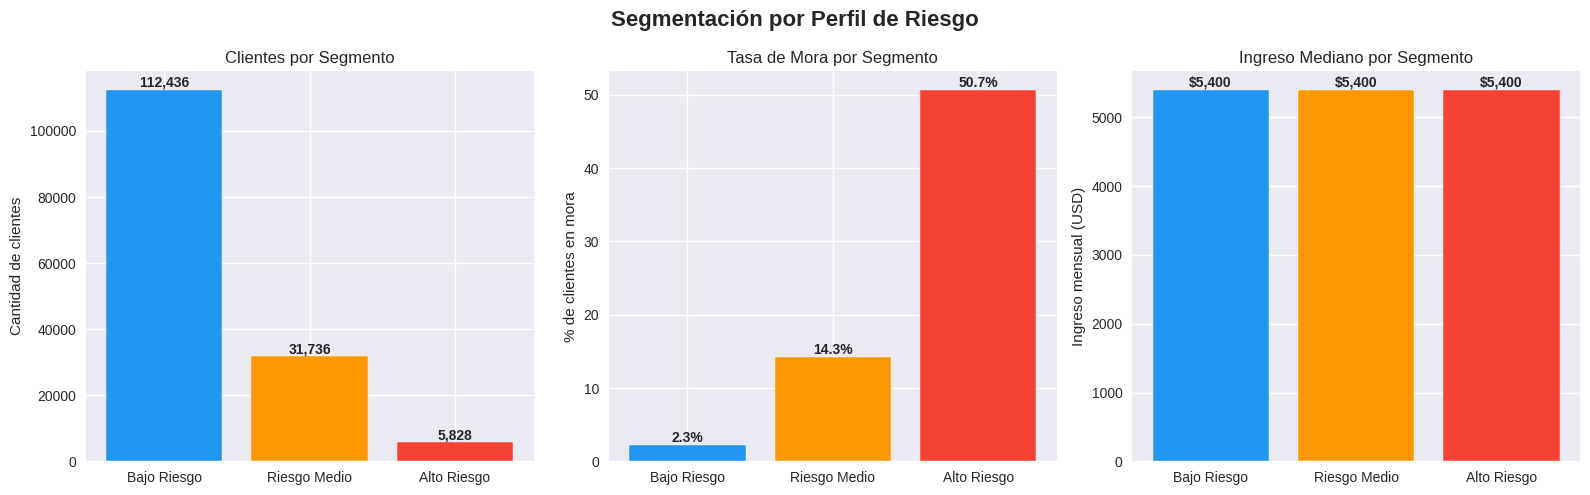

In [ ]:
# ============================================
# SEGMENTACIÓN POR PERFIL DE RIESGO
# VISUALIZACIÓN DE SEGMENTACIÓN
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Segmentación por Perfil de Riesgo', fontsize=16, fontweight='bold')

colores = {'Bajo Riesgo': '#2196F3', 'Riesgo Medio': '#FF9800', 'Alto Riesgo': '#F44336'}
orden = ['Bajo Riesgo', 'Riesgo Medio', 'Alto Riesgo']

df_viz = df[df['MonthlyIncome'] >= 100].copy()
df['PerfilRiesgo'] = df.apply(clasificar_riesgo, axis=1)

# Gráfico 1 — Distribución de segmentos
conteo = df['PerfilRiesgo'].value_counts()[orden]
bars = axes[0].bar(orden, conteo, color=[colores[x] for x in orden], edgecolor='white')
axes[0].set_title('Clientes por Segmento')
axes[0].set_ylabel('Cantidad de clientes')
for bar in bars:
    axes[0].annotate(f'{bar.get_height():,.0f}',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontweight='bold')

# Gráfico 2 — Tasa de mora por segmento
mora_por_segmento = df.groupby('PerfilRiesgo')['SeriousDlqin2yrs'].mean() * 100
mora_por_segmento = mora_por_segmento[orden]
bars2 = axes[1].bar(orden, mora_por_segmento, color=[colores[x] for x in orden], edgecolor='white')
axes[1].set_title('Tasa de Mora por Segmento')
axes[1].set_ylabel('% de clientes en mora')
for bar in bars2:
    axes[1].annotate(f'{bar.get_height():.1f}%',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontweight='bold')

# Gráfico 3 — Ingreso promedio por segmento
ingreso_por_segmento = df_viz.groupby('PerfilRiesgo')['MonthlyIncome'].median()[orden]
bars3 = axes[2].bar(orden, ingreso_por_segmento, color=[colores[x] for x in orden], edgecolor='white')
axes[2].set_title('Ingreso Mediano por Segmento')
axes[2].set_ylabel('Ingreso mensual (USD)')
for bar in bars3:
    axes[2].annotate(f'${bar.get_height():,.0f}',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 🏦 Recomendaciones para el Banco

1. **Monitoreo preventivo** → Los 31,736 clientes de Riesgo Medio deben
recibir seguimiento activo antes de escalar a Alto Riesgo.

2. **Alerta temprana** → Implementar alertas automáticas cuando un cliente
supere el 75% de utilización de su línea de crédito.

3. **Revisión de ingresos no declarados** → El 19.8% de clientes sin
ingreso registrado representa un punto ciego en el análisis de riesgo.
Se recomienda cruzar con fuentes externas (bureau de crédito, declaraciones fiscales).

4. **Modelo predictivo** → Con este dataset limpio y segmentado, el siguiente
paso natural es construir un modelo de clasificación (Regresión Logística o
Random Forest) para predecir mora con mayor precisión.

In [ ]:
# Exportación del dataset
df.to_csv('credito_limpio.csv', index=False)

print("Archivo exportad correctamente:")
print(f"   credito_limpio.csv → {len(df):,} clientes")

✅ Archivos exportados:
   credito_limpio.csv → 150,000 clientes
   credito_viz.csv → 147,723 clientes
